In [1]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names

# 示例使用
folder_path = 'D:\交作业（大二下）\DLNLP\DL-nlp2025-main\第二次\语料库'
contents, names = read_txt_files_with_different_encodings(folder_path)

for items in contents:
    print("文件内容:", items[500:1000])
print("文件标题:", names)

文件内容: 
文件内容: 个剑客的故事我知道得不全。但反正是写小说，不知道原来出典的，不妨任意创造一个故事。可是连写三十三个剑侠故事的心愿，永远也完成不了的。写了第一篇《越女剑》后，第二篇《虬髯客》的小说就写不下去了。写叙述文比写小说不费力得多，于是改用平铺直叙的方式，介绍原来的故事。其中《虬髯客》、《聂隐娘》、《红线》、《昆仑奴》四个故事众所周知，不再详细叙述，同时原文的文笔极好，我没有能力译成同样简洁明丽的语体文，所以附录了原文。比较生僻的故事则将原文内容全部写了出来。这些短文写于一九七○年一月和二月，是为《明报晚报》创刊最初两个月所作。
　　一 赵处女
　　江苏与浙江到宋朝时已渐渐成为中国的经济与文化中心，苏州、杭州成为出产文化和美女的地方。但在春秋战国时期，吴人和越人却是勇决剽悍的象征。那样的轻视生死，追求生命中最后一刹那的光彩，和现代一般中国人的性格相去是这么遥远，和现代苏浙人士的机智柔和更是两个极端。在那时候，吴人越人血管中所流动的，是原始的、犷野的热血。吴越的文化是外来的。伍子胥、文种、范蠡都来自西方的楚国。勾践的另一个重要谋士计然来自北方的晋国。只有西施本色的美丽，才原来就属于浣纱溪那清澈的
文件内容: 这玩意儿比甚么游戏都好玩，转到门口，推门进去，大叫：“老师，你教我这玩意儿！”
　　这女孩儿李沅芷是总兵李可秀的独生女儿，是他在湘西做参将任内所生，给女儿取这名字，是纪念生地之意。教书先生陆高止是位饱学宿儒，五十四五岁年纪，平日与李沅芷谈古论今，师生间倒也甚是相得。这一天陆高止因受不了青蝇苦扰，发射芙蓉金针，钉死了数十只，哪知却给女弟子在窗外偷看到了。他见李沅芷一张清秀明艳的脸蛋红扑扑地显得甚是兴奋，当下淡淡的道：“唔，怎么不跟女伴去玩儿，想听诸葛亮三气周瑜的故事，是不是？”李沅芷道：“老师，你教我这好玩的法儿？”陆高止道：“甚么法儿呀？”
　　李沅芷道：“用金针钉苍蝇的法儿。”说着搬了张椅子，纵身跳上，细细瞧了一会，把钉在苍蝇身上的金针一枚枚拔下来，用纸抹拭干净，交还老师，说道：“老师，我知道，你这不是玩意儿，是非常高明的武功，你非教我不可。”她有时跟随父亲在练武场上盘马弯弓，也学过一些武艺。陆高止微笑道：“你要学武功，扶风城周围几百里地，谁也及不上你爹爹武艺高强。”李沅芷道：“我爹爹只会用弓箭射鹰，可不会用金针射苍蝇，你若不信，我便问爹爹去，看他

In [2]:
def load_words_from_file(file_path):
    """从文件中读取内容并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set):
    """去除文本中的标点符号和停用词"""
    # 去除标点符号
    text = ''.join(char for char in text if char not in punctuation_set)
    # 去除停用词
    words = text.split()
    words = [word for word in words if word not in stopwords_set]
    return ' '.join(words)

def process_text_list(text_list, punctuation_file, stopwords_file):
    """处理文本列表，去除标点符号和停用词"""
    # 加载标点符号和停用词
    punctuation_set = load_words_from_file(punctuation_file)
    stopwords_set = load_words_from_file(stopwords_file)
    print(stopwords_set)
    
    # 处理每个文本
    processed_list = []
    for text in text_list:
        processed_text = remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set)
        processed_list.append(processed_text)
    
    return processed_list

# 示例使用
text_list = contents
punctuation_file = 'cn_punctuation.txt'
stopwords_file = 'cn_stopwords.txt'

processed_list = process_text_list(text_list, punctuation_file, stopwords_file)

for items in processed_list:
    print(items[:2000])


{'你', '为什么', '宁愿', '看', '本人', '再则', '这次', '叫', '可以', '要', '照', '”', '嘘', '人们', '另一方面', '第', '除此之外', '一转眼', '何况', '如此', "'", '可见', '恰恰相反', '这个', '哪天', '倘使', '任凭', '呕', '一样', '莫如', '己', '怎样', '哩', '果然', '同时', '旁人', '来自', '正如', '非徒', '乃至', '凭', '要是', '阿', '自各儿', '既然', '随', '怎', '当然', '至于', '或', '此时', '没奈何', '哪里', '除开', '于', '啐', '呜', '哪边', '仍旧', '吓', '哪些', '那儿', '尔尔', '是以', '连', '该', '不过', '自个儿', '处在', '望', '不料', '！', '如何', '怎么', '是', '向着', '这样', '啊', '的确', '说来', '．', '矣', '打从', '或曰', '因着', '哎哟', '即或', '具体说来', '与此同时', '漫说', '它们', '纵然', '至', '般的', '这么些', '纵', '依照', '据', '不比', '此次', '如同', '惟其', '还是', '们', '然则', '他', '既往', '即如', '0', '诸如', '比如', '今', '别的', '嘿', '以及', '向', '因此', '某', '趁', '正是', '当着', '无', '加以', '⑤', '依据', '总的来看', '仍', '能', '自家', '前者', '嘛', '一些', '怎么样', '唯有', '甚且', '用', '巴', '谁料', '嘎', '甚么', '赶', '为何', '全部', '其中', '哗', '俺', '嗡嗡', '自己', '乌乎', '（', '万一', '自从', '设若', '赖以', '矣哉', '矣乎', '由此可见', '哈', '喏', '再其次', '果真', '让', '咚', '有些', '鉴于', '随时', '还', '朝着', '譬如', '哪样', '经过', '只有', '即

In [3]:
import re

def split_chinese_strings_to_char_lists(input_list):
    """
    将列表中的每个中文字符串拆分为单个中文字符，并返回一个子列表的列表。

    参数:
    input_list (list): 包含中文字符串的列表。

    返回:
    list: 每个字符串被拆分为单个中文字符的子列表的列表。
    """
    return [[char for char in string if re.match(r'[\u4e00-\u9fff]', char)] for string in input_list]

# 示例使用
input_list = processed_list
processed_list = split_chinese_strings_to_char_lists(input_list)

In [4]:
import random

def extract_paragraphs(tokenized_texts, num_paragraphs=1000, paragraph_length=1000):
    paragraphs = []  # 存储抽取的段落
    source_indices = []  # 存储段落的来源文本索引

    # 确保输入的文本足够长以抽取段落
    valid_texts = [text for text in tokenized_texts if len(text) >= paragraph_length]
    if not valid_texts:
        raise ValueError("没有足够长的文本可供抽取段落。")

    for _ in range(num_paragraphs):
        # 随机选择一个文本
        source_index = random.randint(0, len(valid_texts) - 1)
        source_text = valid_texts[source_index]

        # 随机抽取一个段落
        start = random.randint(0, len(source_text) - paragraph_length)
        paragraph = source_text[start:start + paragraph_length]

        # 存储段落及其来源索引
        paragraphs.append(paragraph)
        source_indices.append(source_index)

    return paragraphs, source_indices

# 示例输入数据（假设这是分词后的文本列表）
tokenized_texts = processed_list

# 抽取段落
paragraphs, source_indices = extract_paragraphs(tokenized_texts)

# 输出结果
print(f"抽取了 {len(paragraphs)} 个段落。")
print(f"第一个段落：{paragraphs[0]}")
print(f"第一个段落的来源文本索引：{source_indices[0]}")

抽取了 1000 个段落。
第一个段落：['到', '迷', '宫', '之', '前', '只', '见', '苏', '普', '手', '舞', '长', '刀', '正', '在', '大', '叫', '大', '嚷', '该', '死', '的', '恶', '鬼', '你', '害', '死', '了', '阿', '曼', '连', '我', '也', '一', '起', '害', '死', '吧', '阿', '曼', '死', '了', '我', '也', '不', '要', '活', '了', '我', '是', '苏', '普', '你', '出', '来', '我', '跟', '你', '决', '斗', '你', '怕', '了', '我', '吗', '他', '伸', '手', '去', '转', '门', '环', '但', '心', '神', '混', '乱', '之', '下', '转', '来', '转', '去', '都', '推', '不', '开', '门', '苏', '鲁', '克', '在', '一', '旁', '叫', '道', '苏', '普', '傻', '小', '子', '别', '进', '去', '苏', '普', '却', '那', '里', '肯', '听', '李', '文', '秀', '见', '到', '他', '这', '般', '痴', '情', '的', '模', '样', '心', '中', '又', '是', '一', '酸', '大', '声', '道', '阿', '曼', '没', '有', '死', '苏', '普', '陡', '然', '间', '听', '到', '这', '句', '话', '脑', '筋', '登', '时', '清', '醒', '了', '转', '身', '问', '道', '阿', '曼', '没', '有', '死', '你', '怎', '怎', '麽', '知', '道', '李', '文', '秀', '道', '迷', '宫', '里', '的', '不', '是', '恶', '鬼', '是', '人', '苏', '普', '苏', '鲁', '克', '车', '尔', '库', '三', '人', '齐', '声',

In [5]:
from gensim.models import LdaModel
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

In [6]:
# 假设text_fragments是文本片段的分词列表，text_indices是对应的文本索引
text_fragments = processed_list
text_indices = range(len(processed_list))

In [7]:
from sklearn import svm
from gensim.models import LdaModel
import numpy as np

# 假设你已经有了训练好的LDA模型和训练数据
# lda_model: 训练好的LDA模型
# train_tokenized_texts: 第一个列表，包含分词后的文本片段
# train_text_indices: 第二个列表，包含每个文本片段对应的文本索引
from gensim.corpora import Dictionary


def transform_to_lda_features(lda_model, tokenized_texts):
    """
    将分词后的文本片段转换为LDA主题分布向量
    """
    lda_features = []
    for tokens in tokenized_texts:
        # 手动构建词袋模型
        bow = [(lda_model.id2word.token2id[token], 1) for token in tokens if token in lda_model.id2word.token2id]
        topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
        topic_vector = [prob for _, prob in topic_distribution]  # 提取主题概率
        lda_features.append(topic_vector)
    return np.array(lda_features)



def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()



In [8]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(y_true, y_pred):
    """
    计算模型预测的准确率

    参数:
    y_true (list): 真实的文本索引列表
    y_pred (list): 模型预测的文本索引列表

    返回:
    float: 预测准确率
    """
    return accuracy_score(y_true, y_pred)


开始处理 K=20, T=10
段落抽取 - 内存: 0.23MB | 耗时: 0.00s

============================== K=20 T=10 第1折交叉验证 ==============================
LDA训练 - 内存: 6.52MB | 耗时: 2.36s
特征转换 - 内存: 0.44MB | 耗时: 0.46s
[LibSVM]SVM训练 - 内存: 0.14MB | 耗时: 0.05s
Fold 1 准确率: 0.1100
预测评估 - 内存: 0.02MB | 耗时: 0.01s

============================== K=20 T=10 第2折交叉验证 ==============================
LDA训练 - 内存: 5.40MB | 耗时: 2.22s
特征转换 - 内存: 0.19MB | 耗时: 0.44s
[LibSVM]SVM训练 - 内存: 0.07MB | 耗时: 0.04s
Fold 2 准确率: 0.1100
预测评估 - 内存: 0.00MB | 耗时: 0.01s

============================== K=20 T=10 第3折交叉验证 ==============================
LDA训练 - 内存: -0.97MB | 耗时: 2.30s
特征转换 - 内存: 0.00MB | 耗时: 0.47s
[LibSVM]SVM训练 - 内存: 0.00MB | 耗时: 0.05s
Fold 3 准确率: 0.1200
预测评估 - 内存: 0.00MB | 耗时: 0.01s

============================== K=20 T=10 第4折交叉验证 ==============================
LDA训练 - 内存: 1.06MB | 耗时: 2.33s
特征转换 - 内存: 0.00MB | 耗时: 0.44s
[LibSVM]SVM训练 - 内存: 0.00MB | 耗时: 0.06s
Fold 4 准确率: 0.1600
预测评估 - 内存: 0.00MB | 耗时: 0.01s

============================== 

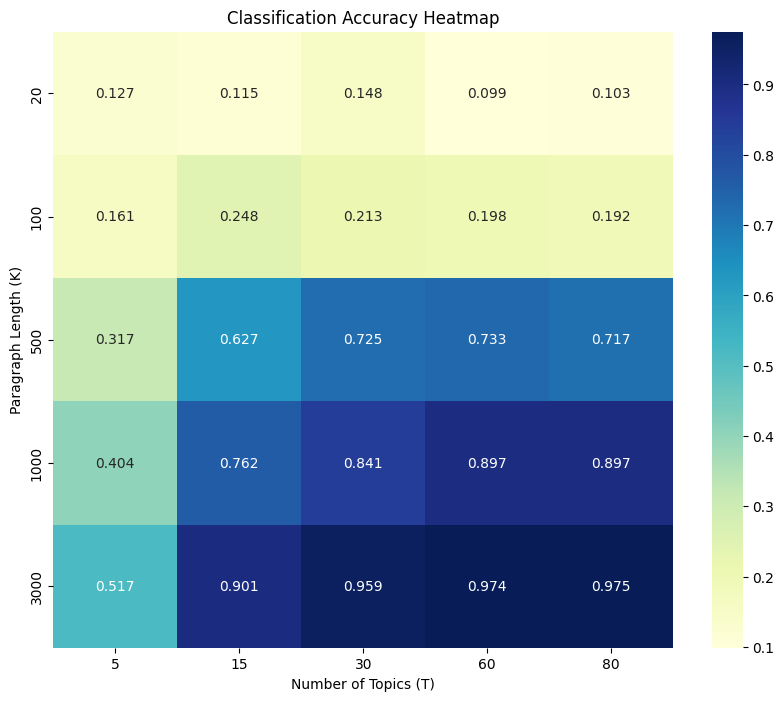

In [9]:
import numpy as np
from sklearn.model_selection import KFold
from joblib import Parallel, delayed
import psutil
import time
from contextlib import contextmanager
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# 超参数设置
LLL1 = [20, 100, 500, 1000, 3000]  # K值列表
TTT1 = [5, 15, 30, 60, 80]              # T值列表
MMMMM = 1000                        # 最大段落长度
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
N_SPLITS = 10                       # 交叉验证次数

@contextmanager
def memory_monitor(label):
    """带超时机制的内存监控"""
    proc = psutil.Process()
    start_mem = proc.memory_info().rss / 1024 / 1024
    start_time = time.time()
    timeout = 3600  # 1小时超时
    
    try:
        yield
    finally:
        if time.time() - start_time > timeout:
            raise TimeoutError(f"{label} 执行超时")
        end_mem = proc.memory_info().rss / 1024 / 1024
        print(f"{label} - 内存: {end_mem-start_mem:.2f}MB | 耗时: {time.time()-start_time:.2f}s")

def cross_validate(processed_list, paragraphs, source_indices, K, T):
    """执行10折交叉验证的核心函数"""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_accuracies = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(paragraphs), 1):
        print(f"\n{'='*30} K={K} T={T} 第{fold}折交叉验证 {'='*30}")
        
        # 划分训练测试集
        train_para = [paragraphs[i] for i in train_idx]
        test_para = [paragraphs[i] for i in test_idx]
        train_src = [source_indices[i] for i in train_idx]
        test_src = [source_indices[i] for i in test_idx]
        
        # LDA训练
        with memory_monitor("LDA训练"):
            dictionary = Dictionary(processed_list)
            corpus = [dictionary.doc2bow(text) for text in processed_list]
            lda_model = LdaModel(
                corpus=corpus,
                id2word=dictionary,
                num_topics=T,
                chunksize=1000,
                passes=1,
                iterations=50
            )
        
        # 特征转换
        with memory_monitor("特征转换"):
            X_train = transform_to_lda_features(lda_model, train_para)
            X_test = transform_to_lda_features(lda_model, test_para)
        
        # SVM训练（简化参数）
        with memory_monitor("SVM训练"):
            svm_model = svm.SVC(
                C=10,  # 使用经验值避免网格搜索
                kernel='rbf',
                gamma='scale',
                verbose=True
            )
            svm_model.fit(X_train, train_src)
        
        # 评估
        with memory_monitor("预测评估"):
            pred = svm_model.predict(X_test)
            acc = calculate_accuracy(test_src, pred)
            fold_accuracies.append(acc)
            print(f"Fold {fold} 准确率: {acc:.4f}")
    
    return np.mean(fold_accuracies), np.std(fold_accuracies)

def process_k_t_value(K, T, processed_list):
    """处理单个K和T值的完整流程（带交叉验证）"""
    print(f"\n{'='*40}\n开始处理 K={K}, T={T}\n{'='*40}")
    
    try:
        # 阶段1: 数据准备
        with memory_monitor("段落抽取"):
            paragraphs, source_indices = extract_paragraphs(
                processed_list, MMMMM, K
            )
        
        # 执行交叉验证
        mean_acc, std_acc = cross_validate(processed_list, paragraphs, source_indices, K, T)
        
        print(f"\nK={K}, T={T} 交叉验证结果: {mean_acc:.4f} ± {std_acc:.4f}")
        return (K, T, mean_acc, std_acc)
    
    except Exception as e:
        print(f"K={K}, T={T} 处理失败: {str(e)}")
        return (K, T, 0, 0)

def create_heatmap(results):
    """根据结果创建热力图"""
    # 准备数据
    K_values = sorted(list(set(r[0] for r in results)))
    T_values = sorted(list(set(r[1] for r in results)))
    
    # 创建准确率矩阵
    acc_matrix = np.zeros((len(K_values), len(T_values)))
    for r in results:
        k_idx = K_values.index(r[0])
        t_idx = T_values.index(r[1])
        acc_matrix[k_idx, t_idx] = r[2]
    
    # 绘制热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(acc_matrix, 
                annot=True, 
                fmt=".3f",
                xticklabels=T_values,
                yticklabels=K_values,
                cmap="YlGnBu")
    plt.xlabel("Number of Topics (T)")
    plt.ylabel("Paragraph Length (K)")
    plt.title("Classification Accuracy Heatmap")
    plt.savefig("accuracy_heatmap.png")
    plt.show()

# 主执行流程
if __name__ == "__main__":
    # 小规模测试
    test_results = []
    for K in [20, 100]:
        for T in [10, 30]:
            _, _, acc, std = process_k_t_value(K, T, processed_list)
            test_results.append(acc > 0)
            print(f"K={K}, T={T} 测试完成: {acc:.4f} ± {std:.4f}")
    
    if all(test_results):
        print("\n小K/T值测试成功，开始完整运行...")
        # 生成所有K和T的组合
        param_combinations = [(K, T) for K in LLL1 for T in TTT1]
        
        # 限制并行进程数
        results = Parallel(n_jobs=4)(
            delayed(process_k_t_value)(K, T, processed_list)
            for K, T in param_combinations
        )
        
        # 结果展示
        print("\n最终交叉验证结果:")
        for K, T, acc, std in results:
            print(f"K={K:<5} T={T:<3} 平均准确率: {acc:.4f} ± {std:.4f}")
        
        # 创建热力图
        create_heatmap(results)
    else:
        print("\n小K/T值测试失败，请检查错误")

In [10]:
import pandas as pd

def save_results_to_excel(results, filename="zi_sss.xlsx"):
    """
    将实验结果保存到Excel文件
    参数:
        results: 包含(K, T, 平均准确率, 标准差)的元组列表
        filename: 输出的Excel文件名
    """
    # 转换为DataFrame
    df = pd.DataFrame(results, columns=['K', 'T', 'Mean Accuracy', 'Std'])
    
    # 按K和T排序
    df = df.sort_values(by=['K', 'T'])
    
    # 保存到Excel
    df.to_excel(filename, index=False, float_format="%.4f")
    print(f"结果已保存到 {filename}")

# 使用示例（假设results是主程序中的结果列表）
if __name__ == "__main__":
    # 示例数据 - 实际使用时替换为你的results变量
    example_results = results
    
    save_results_to_excel(example_results)

结果已保存到 zi_sss.xlsx


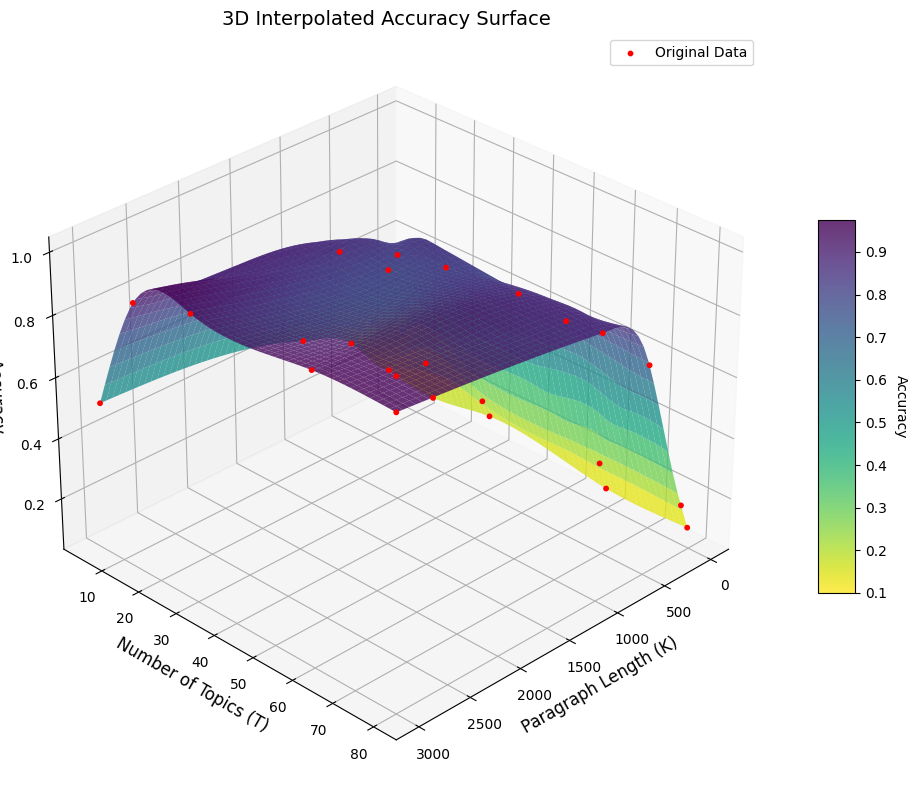

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from matplotlib import cm

# 假设results是之前代码运行得到的结果列表，格式为[(K1,T1,acc1,std1), (K2,T2,acc2,std2), ...]
# 这里使用您提供的热力图数据创建示例results

# 准备数据
K = np.array([r[0] for r in results])
T = np.array([r[1] for r in results])
accuracy = np.array([r[2] for r in results])

# 创建插值网格
K_grid = np.linspace(min(K), max(K), 50)
T_grid = np.linspace(min(T), max(T), 50)
K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)

# 使用三次插值方法
accuracy_interp = griddata(
    (K, T), accuracy, (K_mesh, T_mesh), method='cubic'
)

# 创建3D图形
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制曲面（z值越大颜色越深）
surf = ax.plot_surface(
    K_mesh, T_mesh, accuracy_interp,
    cmap=cm.viridis_r,  # 使用反向的viridis色图
    edgecolor='none',
    alpha=0.8,
    vmin=min(accuracy),  # 设置颜色范围
    vmax=max(accuracy)
)

# 添加原始数据点
ax.scatter(K, T, accuracy, c='red', s=10, alpha=1, label='Original Data')

# 设置坐标轴标签
ax.set_xlabel('Paragraph Length (K)', fontsize=12)
ax.set_ylabel('Number of Topics (T)', fontsize=12)
ax.set_zlabel('Accuracy', fontsize=12)
ax.set_title('3D Interpolated Accuracy Surface', fontsize=14)

# 添加颜色条
cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.set_label('Accuracy', rotation=270, labelpad=15)

# 调整视角
ax.view_init(elev=30, azim=45)

# 显示图例和图形
ax.legend()
plt.tight_layout()
plt.show()